<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/nova_V488Sge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/nova_V488Sge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova V488 Sge (Nova Sagittae 2026) — spectre Alpy 600

**Contexte** : PNV J19450648+1822422, découverte le 2026-08-25 (NMW-TexasTech), pic vers V ≈ 6–7, profils P Cygni en Hα/Hβ à ~1500 km/s le soir de la découverte, déclin rapide (V ≈ 9.5 au 1er septembre → nova *rapide*). Distance Gaia du progéniteur ≈ 6.3 kpc ; le progéniteur est un candidat binaire à éclipses (P ≈ 9.9 j, donc probablement un compagnon évolué).

Contenu du notebook :
1. chargement du FITS 1D, âge de la nova au moment de l'observation ;
2. **vue sobre** (linéaire + log, la vue log est indispensable en phase nébulaire : Hα écrase tout) ;
3. **vue colorisée** λ→RGB sous la courbe (même méthode que 2026rdg) avec **raies annotées** et étiquettes étagées ;
4. **pseudo-continuum global** par points de continu (à valider visuellement) ;
5. **largeurs de raies** (FWHM, FW10 %, déconvolution instrumentale, ajustement gaussien, superposition en vitesse) ;
6. **diagnostic de phase** : flux des raies clés relatifs à Hβ et classification indicative de type Tololo (P / A / N / C).

In [4]:
# --- Chargement (Colab) ---
try:
    from google.colab import files
    uploaded = files.upload()          # sélectionner le .fit
    FILE = list(uploaded.keys())[0]
except ImportError:                    # exécution locale
    FILE = 'V488Sge.fit'

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time

# --- Paramètres à ajuster ---
OBJECT   = 'Nova V488 Sge'
SETUP    = 'Jean Phi N — Newton 200 / Alpy 600 / Atik 414EX'
R_INST   = 500                         # pouvoir de résolution effectif (mesuré sur la lampe si possible)
T0_ISO   = '2026-08-25T10:39:00'       # découverte (2026-08-25.444 UT) ; remplacer par la date du max si tu préfères
XLIM     = (3800, 7400)

Saving _v488_sge_20260926_890.fits to _v488_sge_20260926_890 (1).fits


In [5]:
def load_spectrum(path):
    """(wavelength [Å], flux, meta) depuis un FITS 1D linéaire (ISIS)."""
    with fits.open(path) as hdul:
        h = hdul[0].header
        flux = hdul[0].data.astype(float).squeeze()
        n = h['NAXIS1']
        crpix = h.get('CRPIX1', 1)
        wl = h['CRVAL1'] + (np.arange(n) + 1 - crpix) * h['CDELT1']
        meta = {'date': h.get('DATE-OBS', None), 'exptime': h.get('EXPTIME', np.nan)}
    return wl, flux, meta

wl, flux, meta = load_spectrum(FILE)
good = np.isfinite(flux)
wl, flux = wl[good], flux[good]

t_obs = Time(meta['date']) if meta['date'] else None
t0    = Time(T0_ISO)
AGE   = (t_obs - t0).jd if t_obs is not None else np.nan
DATE_LABEL = t_obs.isot[:16].replace('T', ' ') + ' UT' if t_obs is not None else '?'

print(f"{wl[0]:.1f}–{wl[-1]:.1f} Å, {len(wl)} pts, dispersion {np.median(np.diff(wl)):.2f} Å/pix")
print(f"DATE-OBS = {meta['date']}   EXPTIME = {meta['exptime']} s")
print(f"Âge depuis T0 : t = {AGE:.2f} j")

# normalisation pour l'affichage : pic de Hα = 1 (le continuum est faible chez une nova évoluée)
m_ha = (wl > 6500) & (wl < 6630)
FNORM = np.nanmax(flux[m_ha]) if m_ha.any() else np.nanmax(flux)
fn = flux / FNORM

3575.5–7370.0 Å, 7590 pts, dispersion 0.50 Å/pix
DATE-OBS = 2026-09-26T21:21:53   EXPTIME = 1553 s
Âge depuis T0 : t = 32.45 j


## 1. Vue sobre
Deux panneaux : échelle linéaire (Hα = 1) et échelle logarithmique, qui fait ressortir les raies faibles (He II, [N II] 5755, raies coronales…).

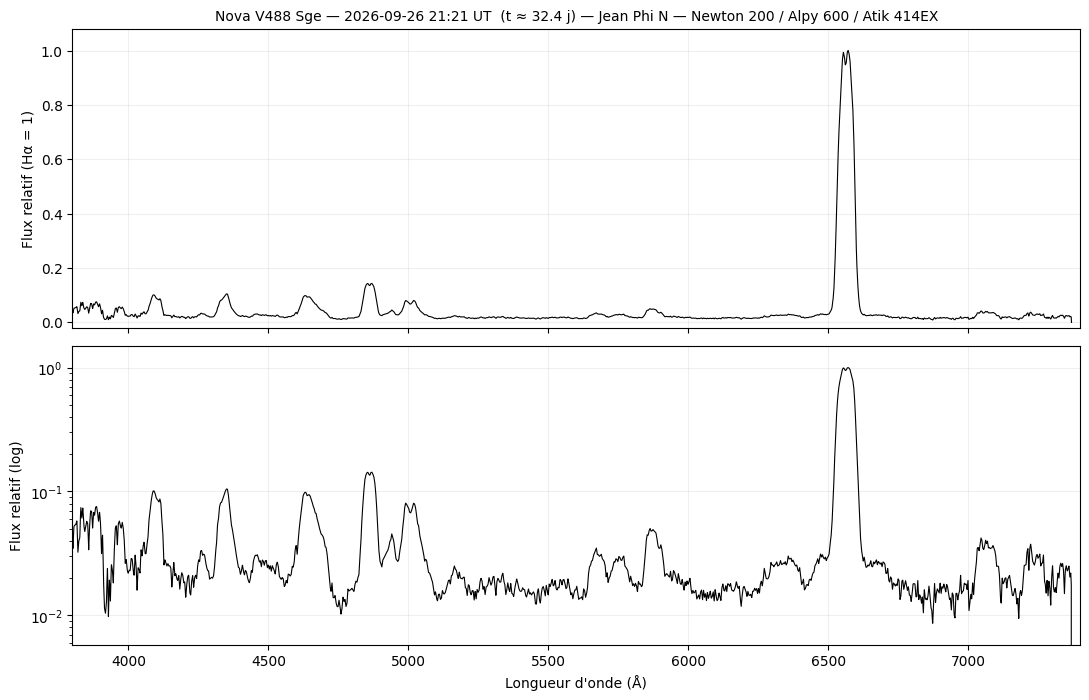

In [6]:
def plot_sober(wl, fn, xlim=XLIM, annotate=False):
    m = (wl >= xlim[0]) & (wl <= xlim[1])
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                 gridspec_kw={'hspace': 0.06})
    for ax in (a1, a2):
        ax.plot(wl[m], fn[m], color='k', lw=0.8)
        ax.grid(alpha=0.2)
    a1.set_ylim(-0.02, 1.08)
    a1.set_ylabel('Flux relatif (Hα = 1)')
    pos = fn[m][fn[m] > 0]
    a2.set_yscale('log')
    a2.set_ylim(np.percentile(pos, 1) * 0.5, 1.5)
    a2.set_ylabel('Flux relatif (log)')
    a2.set_xlabel("Longueur d'onde (Å)")
    a2.set_xlim(xlim)
    a1.set_title(f'{OBJECT} — {DATE_LABEL}  (t ≈ {AGE:.1f} j) — {SETUP}', fontsize=10)
    if annotate:
        annotate_lines(a2, xlim, log=True)
    plt.show()

# (annotate_lines est définie plus bas ; relancer avec annotate=True après la section 2)
plot_sober(wl, fn)

## 2. Liste de raies et annotation

Liste adaptée à une nova rapide **~1 mois** après l'éruption : Balmer, He I, He II / Bowen, raies interdites nébulaires et aurorales, O I, restes de Fe II, et raies coronales possibles. Mettre `show=False` (ou commenter) ce qui n'est pas vu.

Les étiquettes sont automatiquement réparties sur 3 niveaux pour éviter les chevauchements.

In [7]:
# (label, λ Å, catégorie, show)
LINES = [
    ("[Ne III] 3869",  3868.8, 'neb',    True),
    ("Hε+[Ne III]",    3969.0, 'balmer', True),
    ("Hδ",             4101.7, 'balmer', True),
    ("Hγ",             4340.5, 'balmer', True),
    ("[O III] 4363",   4363.2, 'aur',    True),
    ("He I 4471",      4471.5, 'hei',    True),
    ("N III 4640",     4640.0, 'n',      True),   # fluorescence de Bowen
    ("He II 4686",     4685.7, 'heii',   True),
    ("Hβ",             4861.3, 'balmer', True),
    ("[O III] 4959",   4958.9, 'neb',    True),
    ("[O III] 5007",   5006.8, 'neb',    True),
    ("Fe II 5169",     5169.0, 'fe',     False),  # dominant au début, en principe disparu
    ("He II 5411",     5411.5, 'heii',   True),
    ("[N II] 5755",    5754.6, 'aur',    True),
    ("He I 5876",      5875.6, 'hei',    True),
    ("[Fe VII] 6087",  6086.9, 'cor',    True),
    ("[O I] 6300",     6300.3, 'neb',    True),
    ("[O I] 6364",     6363.8, 'neb',    True),
    ("[Fe X] 6375",    6374.5, 'cor',    True),
    ("[N II] 6548",    6548.0, 'neb',    False),
    ("Hα",             6562.8, 'balmer', True),
    ("[N II] 6583",    6583.5, 'neb',    True),
    ("He I 6678",      6678.2, 'hei',    True),
    ("He I 7065",      7065.2, 'hei',    True),
    ("[Ar III] 7136",  7135.8, 'neb',    True),
    ("[O II] 7325",    7325.0, 'neb',    True),
    ("O I 7773",       7773.4, 'o',      True),
]

CAT_COLORS = {'balmer': 'black', 'hei': 'tab:purple', 'heii': 'tab:red',
              'n': 'tab:green', 'neb': 'tab:blue', 'aur': 'tab:cyan',
              'cor': 'tab:orange', 'fe': 'tab:brown', 'o': 'tab:olive'}

BANDS = [  # telluriques
    ("O$_2$ B", (6867.0, 6884.0)),
    ("H$_2$O",  (7160.0, 7340.0)),
    ("O$_2$ A", (7594.0, 7685.0)),
]

def annotate_lines(ax, xlim, ymax=None, log=False, min_sep=42.0, nlev=3):
    """Traits pointillés + étiquettes verticales étagées pour éviter les chevauchements."""
    y0, y1 = ax.get_ylim()
    lv = []
    for k in range(nlev):
        if log:
            lv.append(10 ** (np.log10(y1) - (0.02 + 0.15 * k) * (np.log10(y1) - np.log10(y0))))
        else:
            lv.append(y1 - (0.02 + 0.15 * k) * (y1 - y0))
    last = [-1e9] * nlev
    for name, lam, cat, show in sorted(LINES, key=lambda t: t[1]):
        if not show or not (xlim[0] <= lam <= xlim[1]):
            continue
        k = next((i for i in range(nlev) if lam - last[i] >= min_sep), int(np.argmin(last)))
        last[k] = lam
        col = CAT_COLORS.get(cat, 'gray')
        ax.plot([lam, lam], [y0, lv[k]], color=col, ls=':', lw=0.6, alpha=0.6, zorder=3)
        ax.text(lam, lv[k], name, rotation=90, ha='center', va='top',
                fontsize=7.5, color=col, zorder=4,
                bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.3))
    for name, (a, b) in BANDS:
        if b >= xlim[0] and a <= xlim[1]:
            ax.axvspan(a, b, color='tab:blue', alpha=0.10, zorder=2)

## 3. Spectre colorisé (λ→RGB sous la courbe) + annotations
Même fonction couleur que pour 2026rdg (approximation CIE de Dan Bruton), rendu par un seul `imshow` clippé sous la courbe. L'axe Y est étendu à ~1.6 × le pic pour loger les étiquettes au-dessus du spectre.

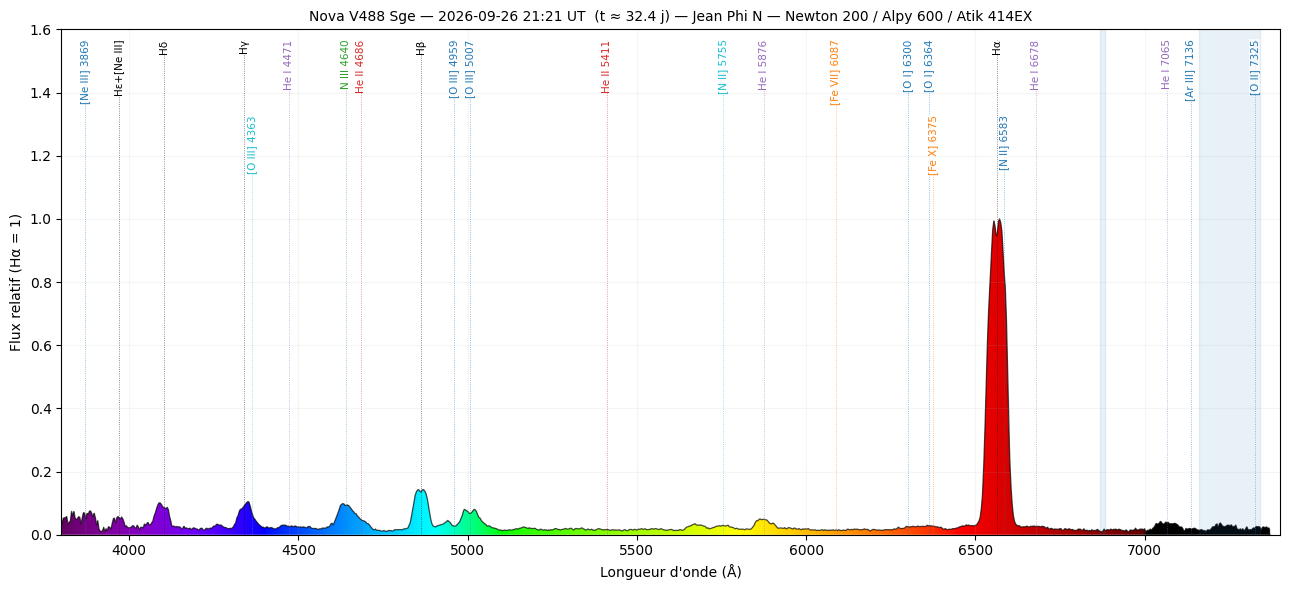

In [8]:
def wavelength_to_rgb(wl_ang, gamma=0.8):
    wl = wl_ang / 10.0
    if wl < 380 or wl > 700:
        return (0.0, 0.0, 0.0)
    if wl < 440:   r, g, b = -(wl - 440) / 60, 0.0, 1.0
    elif wl < 490: r, g, b = 0.0, (wl - 440) / 50, 1.0
    elif wl < 510: r, g, b = 0.0, 1.0, -(wl - 510) / 20
    elif wl < 580: r, g, b = (wl - 510) / 70, 1.0, 0.0
    elif wl < 645: r, g, b = 1.0, -(wl - 645) / 65, 0.0
    else:          r, g, b = 1.0, 0.0, 0.0
    if wl < 420:   f = 0.3 + 0.7 * (wl - 380) / 40
    elif wl > 645: f = 0.3 + 0.7 * (700 - wl) / 55
    else:          f = 1.0
    return ((r * f) ** gamma, (g * f) ** gamma, (b * f) ** gamma)

_wl_grid  = np.arange(3700, 7801, 2.0)
_rgb_grid = np.array([wavelength_to_rgb(w) for w in _wl_grid])
def rgb_at(w):
    return _rgb_grid[np.clip(np.searchsorted(_wl_grid, w), 0, len(_wl_grid) - 1)]

from matplotlib.patches import Polygon

def plot_colored(wl, fn, xlim=XLIM, annotate=True, headroom=1.6):
    m = (wl >= xlim[0]) & (wl <= xlim[1])
    w, y = wl[m], fn[m]
    ybase = min(0.0, np.nanmin(y))
    YMAX = np.nanmax(y) * headroom
    fig, ax = plt.subplots(figsize=(13, 6))
    im = ax.imshow(rgb_at(w)[np.newaxis, :, :], extent=[w[0], w[-1], ybase, YMAX],
                   aspect='auto', origin='lower', zorder=0)
    verts = np.vstack([np.column_stack([w, y]), [[w[-1], ybase], [w[0], ybase]]])
    im.set_clip_path(Polygon(verts, closed=True, transform=ax.transData))
    ax.plot(w, y, color='k', lw=0.9, alpha=0.7, zorder=1)
    ax.set_xlim(xlim); ax.set_ylim(0, YMAX)
    if annotate:
        annotate_lines(ax, xlim)
    ax.set_xlabel("Longueur d'onde (Å)")
    ax.set_ylabel('Flux relatif (Hα = 1)')
    ax.set_title(f'{OBJECT} — {DATE_LABEL}  (t ≈ {AGE:.1f} j) — {SETUP}', fontsize=10)
    ax.grid(alpha=0.12)
    plt.tight_layout(); plt.show()

plot_colored(wl, fn)

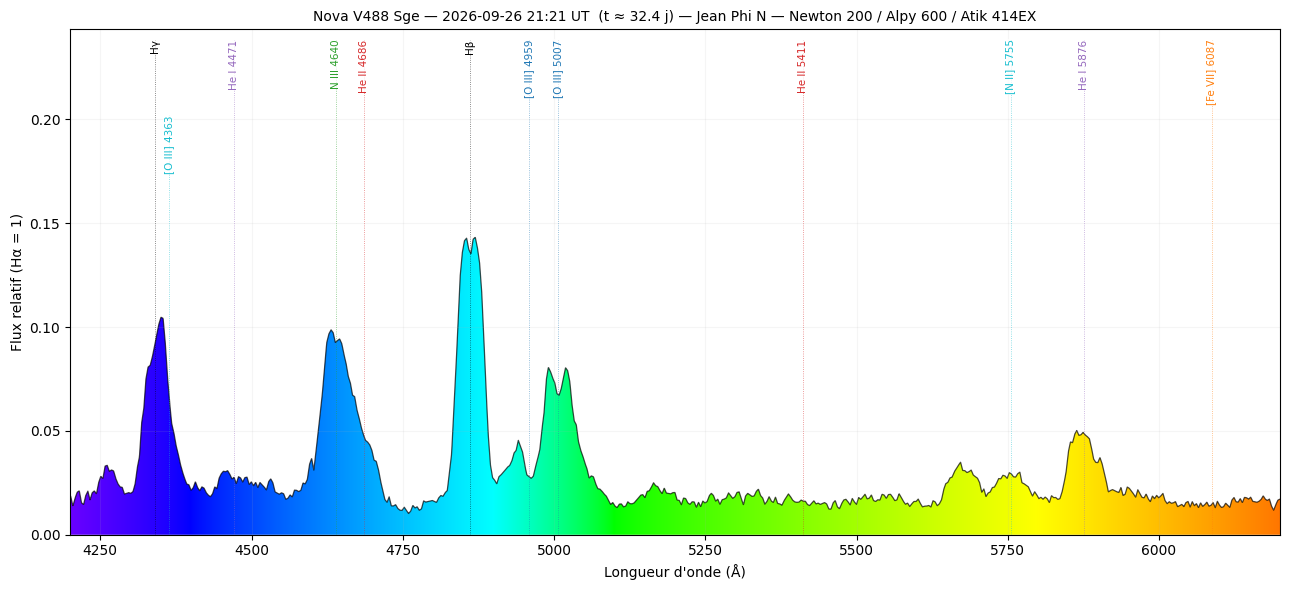

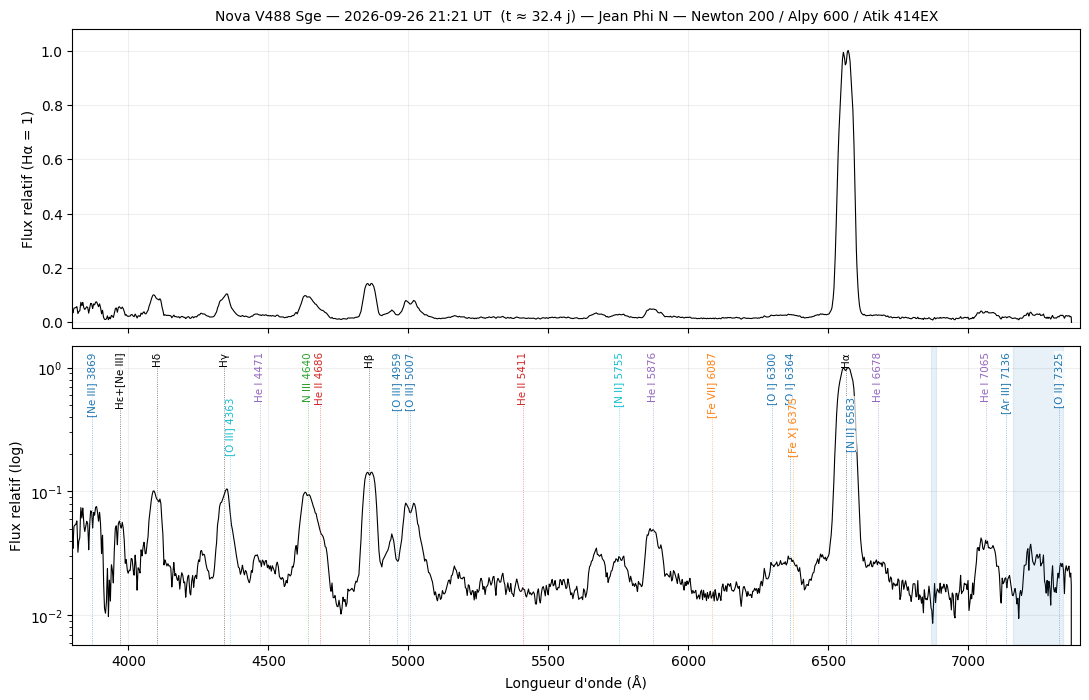

In [9]:
# Vue colorisée zoomée sur le bleu-vert (raies faibles) : on "tronque" Hα
plot_colored(wl, fn, xlim=(4200, 6200), headroom=1.7)
# Vue sobre annotée (log)
plot_sober(wl, fn, annotate=True)

## 4. Pseudo-continuum global
Chez une nova à ce stade le continuum est faible et les ailes des raies se recouvrent : on le définit par une série de **points de continu** (médiane ± `HW` Å), interpolés par PCHIP (pas d'oscillations). **À vérifier sur la figure** et à ajuster (ajouter/retirer des points) avant de mesurer quoi que ce soit.

Bruit par pixel estimé à la manière de DER_SNR (Stoehr et al. 2008).

Bruit par pixel (DER_SNR) ≈ 4.11e-05 (en unités Hα = 1) → S/N au pic de Hα ≈ 24346


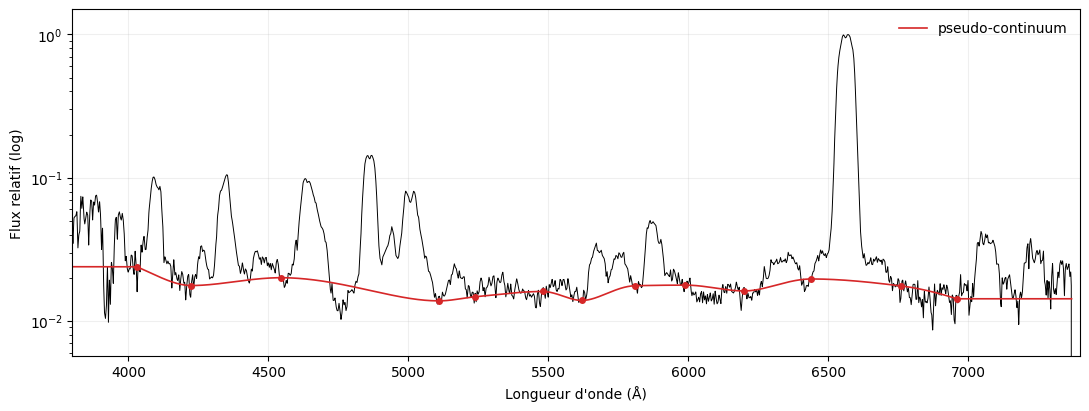

In [10]:
from scipy.interpolate import PchipInterpolator

CONT_POINTS = [4030, 4225, 4545, 5110, 5240, 5480, 5620, 5810, 5990, 6200,
               6440, 6760, 6960, 7420]
HW = 8.0

def build_continuum(wl, f, pts=CONT_POINTS, hw=HW):
    xs, ys = [], []
    for p in pts:
        mm = (wl >= p - hw) & (wl <= p + hw)
        if mm.sum() >= 3:
            xs.append(p); ys.append(np.median(f[mm]))
    xs, ys = np.array(xs), np.array(ys)
    interp = PchipInterpolator(xs, ys, extrapolate=False)
    c = interp(wl)
    c[wl < xs[0]] = ys[0]; c[wl > xs[-1]] = ys[-1]
    return c, xs, ys

def der_snr_noise(f):
    f = f[np.isfinite(f)]
    return 1.482602 / np.sqrt(6.0) * np.median(np.abs(2.0 * f[2:-2] - f[:-4] - f[4:]))

cont, cx, cy = build_continuum(wl, fn)
SIGMA = der_snr_noise(fn)
print(f"Bruit par pixel (DER_SNR) ≈ {SIGMA:.2e} (en unités Hα = 1) → S/N au pic de Hα ≈ {1/SIGMA:.0f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(wl, fn, 'k', lw=0.7)
ax.plot(wl, cont, color='tab:red', lw=1.2, label='pseudo-continuum')
ax.plot(cx, cy, 'o', color='tab:red', ms=4)
ax.set_yscale('log'); ax.set_xlim(XLIM)
ax.set_ylim(np.percentile(fn[fn > 0], 1) * 0.5, 1.5)
ax.legend(frameon=False); ax.grid(alpha=0.2)
ax.set_xlabel("Longueur d'onde (Å)"); ax.set_ylabel('Flux relatif (log)')
plt.show()

## 5. Largeurs de raies

Pour chaque raie : intégration de (flux − continuum) dans une fenêtre, puis
- **FWHM** et **FW10 %** mesurées directement (croisements les plus externes, donc robustes aux profils en « cornes » / plateau), converties en km/s ;
- **déconvolution instrumentale** en quadrature : FWHM_inst = c / R ≈ 600 km/s à R = 500 — c'est non négligeable ;
- ajustement **gaussien** (comparaison seulement : les profils de nova sont rarement gaussiens) ;
- **centroïde** en vitesse (non corrigé héliocentrique, ±30 km/s).

FW10 % / 2 est une bonne approche de la vitesse maximale des éjecta (≈ HWZI). ⚠ Hα contient [N II] 6548/6583, qui élargissent l'aile rouge au fur et à mesure que la nova devient nébulaire.

In [11]:
from scipy.optimize import curve_fit
C_KMS = 299792.458

# (label, λ0, (λmin, λmax) d'intégration)
WIDTH_LINES = [
    ("Hα (+[N II])", 6562.8, (6470, 6655)),
    ("Hβ",           4861.3, (4795, 4915)),
    ("Hγ",           4340.5, (4290, 4385)),
    ("He I 5876",    5875.6, (5830, 5925)),
]

def gauss(x, a, mu, s):
    return a * np.exp(-0.5 * ((x - mu) / s) ** 2)

def _cross(x, y, lev):
    idx = np.where(y >= lev)[0]
    if len(idx) == 0 or idx[0] == 0 or idx[-1] == len(y) - 1:
        return np.nan, np.nan
    i, j = idx[0], idx[-1]
    xl = np.interp(lev, [y[i - 1], y[i]], [x[i - 1], x[i]])
    xr = np.interp(lev, [y[j + 1], y[j]], [x[j + 1], x[j]])
    return xl, xr

def measure_line(label, lam0, win, wl=wl, f=fn, c=cont, R=R_INST):
    m = (wl >= win[0]) & (wl <= win[1])
    x, y = wl[m], f[m] - c[m]
    dl = np.gradient(x)
    F = np.sum(y * dl)
    eF = SIGMA * np.sqrt(m.sum()) * np.median(dl)
    ipk = np.argmax(y); pk = y[ipk]
    xl, xr = _cross(x, y, 0.5 * pk)
    x10l, x10r = _cross(x, y, 0.1 * pk)
    fwhm = (xr - xl) / lam0 * C_KMS
    fw10 = (x10r - x10l) / lam0 * C_KMS
    inst = C_KMS / R
    fwhm_dec = np.sqrt(fwhm**2 - inst**2) if fwhm > inst else np.nan
    cen = np.sum(x * y * dl) / F
    try:
        p, _ = curve_fit(gauss, x, y, p0=[pk, lam0, 15.0])
        fwhm_g = 2.3548 * abs(p[2]) / lam0 * C_KMS
    except Exception:
        p, fwhm_g = None, np.nan
    return dict(label=label, lam0=lam0, x=x, y=y, flux=F, eflux=eF, peak=pk,
                xl=xl, xr=xr, fwhm=fwhm, fwhm_dec=fwhm_dec, fw10=fw10,
                v_cen=(cen - lam0) / lam0 * C_KMS, fwhm_g=fwhm_g, pfit=p)

res = [measure_line(*L) for L in WIDTH_LINES if WIDTH_LINES and wl[0] < L[2][0] and wl[-1] > L[2][1]]

print(f"FWHM instrumentale ≈ {C_KMS/R_INST:.0f} km/s (R = {R_INST})\n")
print(f"{'raie':14s} {'FWHM obs':>9s} {'FWHM déconv':>12s} {'FWHM gauss':>11s} {'FW10%':>7s} {'HWZI≈':>7s} {'v_cen':>7s}   [km/s]")
for r in res:
    print(f"{r['label']:14s} {r['fwhm']:9.0f} {r['fwhm_dec']:12.0f} {r['fwhm_g']:11.0f} "
          f"{r['fw10']:7.0f} {r['fw10']/2:7.0f} {r['v_cen']:+7.0f}")

FWHM instrumentale ≈ 600 km/s (R = 500)

raie            FWHM obs  FWHM déconv  FWHM gauss   FW10%   HWZI≈   v_cen   [km/s]
Hα (+[N II])        2866         2803        2525    3974    1987     +56
Hβ                  2979         2918        2723     nan     nan    +122
Hγ                  2984         2923        3092     nan     nan    +318
He I 5876           2971         2910        2579     nan     nan     +51


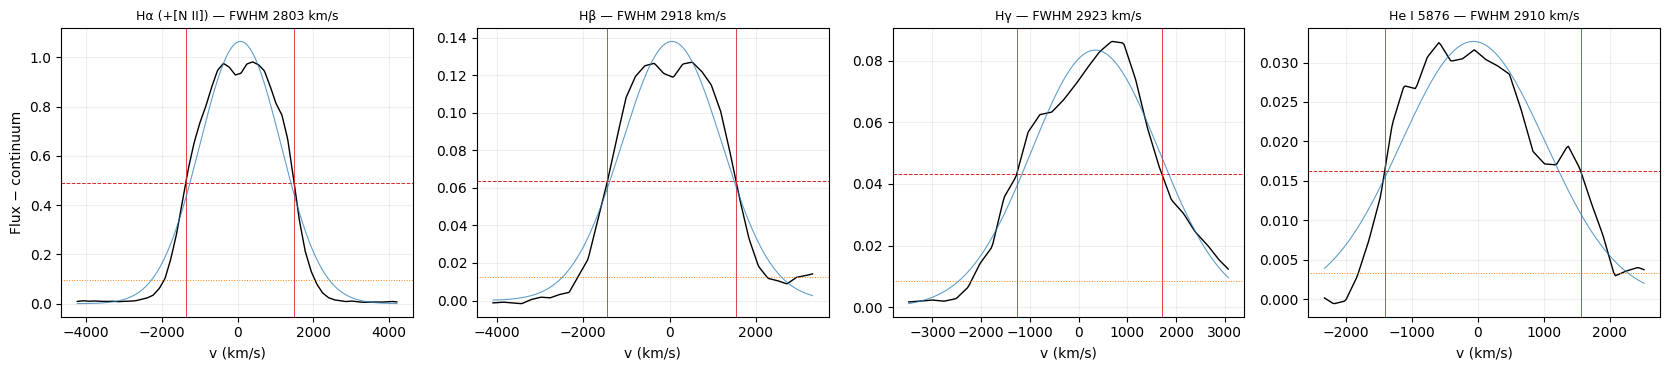

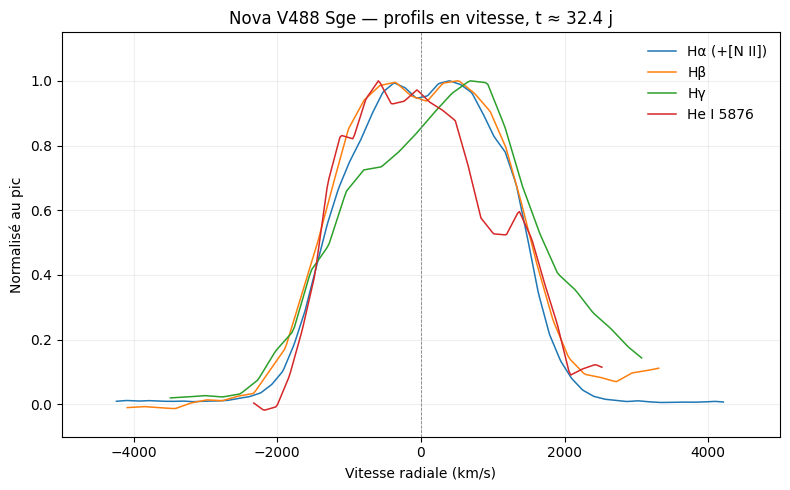

In [12]:
# --- Contrôle visuel des mesures ---
n = len(res)
fig, axs = plt.subplots(1, n, figsize=(4.2 * n, 3.8), squeeze=False)
for ax, r in zip(axs[0], res):
    v = (r['x'] - r['lam0']) / r['lam0'] * C_KMS
    ax.plot(v, r['y'], 'k', lw=1)
    ax.axhline(0.5 * r['peak'], color='tab:red', lw=0.7, ls='--')
    ax.axhline(0.1 * r['peak'], color='tab:orange', lw=0.7, ls=':')
    for xx in (r['xl'], r['xr']):
        ax.axvline((xx - r['lam0']) / r['lam0'] * C_KMS, color='tab:red', lw=0.6)
    if r['pfit'] is not None:
        ax.plot(v, gauss(r['x'], *r['pfit']), color='tab:blue', lw=0.8, alpha=0.7)
    ax.set_title(f"{r['label']} — FWHM {r['fwhm_dec']:.0f} km/s", fontsize=9)
    ax.set_xlabel('v (km/s)'); ax.grid(alpha=0.2)
axs[0][0].set_ylabel('Flux − continuum')
plt.tight_layout(); plt.show()

# --- Superposition des profils en vitesse (normalisés au pic) ---
fig, ax = plt.subplots(figsize=(8, 5))
for r in res:
    v = (r['x'] - r['lam0']) / r['lam0'] * C_KMS
    ax.plot(v, r['y'] / r['peak'], lw=1.1, label=r['label'])
ax.axvline(0, color='gray', lw=0.6, ls='--')
ax.set_xlim(-5000, 5000); ax.set_ylim(-0.1, 1.15)
ax.set_xlabel('Vitesse radiale (km/s)'); ax.set_ylabel('Normalisé au pic')
ax.set_title(f'{OBJECT} — profils en vitesse, t ≈ {AGE:.1f} j')
ax.legend(frameon=False); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## 6. Diagnostic de phase (flux relatifs à Hβ)

Flux intégrés au-dessus du pseudo-continuum dans des fenêtres fixes (à ajuster), rapportés à Hβ = 100, avec S/N. Puis une classification **indicative** inspirée du système de Tololo (Williams et al. 1991) :

- **C** (coronale) si [Fe X] 6375 > [Fe VII] 6087 et détectée ;
- sinon on regarde la raie non-Balmer la plus forte : permise → **P**, aurorale ([N II] 5755) → **A**, nébulaire ([O III] 5007, [Ne III]…) → **N**.

⚠ À R ≈ 500 avec des raies de ~2000 km/s, beaucoup de fenêtres sont blendées : [Fe X] 6375 avec [O I] 6364, He II 4686 avec N III 4640, Hγ avec [O III] 4363, [O III] 4959/5007 avec l'aile rouge de Hβ. Le résultat est une orientation, pas une classification publiable.

In [13]:
# (label, λ0, (λmin, λmax), type)  type ∈ balmer / perm / aur / neb / cor
FLUX_LINES = [
    ("Hβ",             4861.3, (4800, 4915), 'balmer'),
    ("Hα+[N II]",      6562.8, (6470, 6655), 'balmer'),
    ("N III 4640",     4640.0, (4605, 4665), 'perm'),
    ("He II 4686",     4685.7, (4665, 4720), 'perm'),
    ("He I 5876",      5875.6, (5830, 5925), 'perm'),
    ("He I 6678",      6678.2, (6655, 6705), 'perm'),
    ("He I 7065",      7065.2, (7035, 7100), 'perm'),
    ("Fe II 5169",     5169.0, (5150, 5190), 'perm'),
    ("O I 7773",       7773.4, (7745, 7805), 'perm'),
    ("[N II] 5755",    5754.6, (5720, 5795), 'aur'),
    ("[O III] 4959",   4958.9, (4930, 4982), 'neb'),
    ("[O III] 5007",   5006.8, (4982, 5045), 'neb'),
    ("[Ne III] 3869",  3868.8, (3845, 3895), 'neb'),
    ("[O I] 6300",     6300.3, (6275, 6330), 'neb'),
    ("[Ar III] 7136",  7135.8, (7115, 7160), 'neb'),
    ("[Fe VII] 6087",  6086.9, (6060, 6115), 'cor'),
    ("[Fe X] 6375",    6374.5, (6362, 6395), 'cor'),
]

def line_flux(win):
    m = (wl >= win[0]) & (wl <= win[1])
    if m.sum() < 3:
        return np.nan, np.nan
    dl = np.median(np.diff(wl))
    return np.sum((fn[m] - cont[m])) * dl, SIGMA * np.sqrt(m.sum()) * dl

tab = []
for name, lam, win, typ in FLUX_LINES:
    if wl[0] <= win[0] and wl[-1] >= win[1]:
        F, eF = line_flux(win)
        tab.append((name, lam, typ, F, eF))
FHB = next(F for n_, _, _, F, _ in tab if n_ == 'Hβ')

print(f"{'raie':16s} {'type':7s} {'F/F(Hβ)×100':>12s} {'S/N':>6s}")
for name, lam, typ, F, eF in tab:
    print(f"{name:16s} {typ:7s} {100*F/FHB:12.1f} {F/eF:6.1f}")

# --- Classification indicative ---
det = {n_: F for n_, _, _, F, eF in tab if F / eF > 3}
typ_of = {n_: t for n_, _, t, _, _ in tab}
if det.get('[Fe X] 6375', 0) > det.get('[Fe VII] 6087', 0) > 0 or    ('[Fe X] 6375' in det and '[Fe VII] 6087' not in det):
    phase = 'C (coronale) — ⚠ vérifier le blend avec [O I] 6364'
else:
    nb = {k: v for k, v in det.items() if typ_of[k] != 'balmer'}
    if nb:
        top = max(nb, key=nb.get)
        phase = {'perm': 'P (permise)', 'aur': 'A (aurorale)', 'neb': 'N (nébulaire)',
                 'cor': 'C (coronale)'}[typ_of[top]] + f' — raie non-Balmer la plus forte : {top}'
    else:
        phase = 'indéterminée (aucune raie non-Balmer à S/N > 3)'
print(f"\nPhase indicative (type Tololo) : {phase}")

if 'Hα+[N II]' in det:
    print(f"Hα+[N II] / Hβ = {det['Hα+[N II]']/FHB:.2f}  "
          "(décrément de Balmer : significatif seulement si le spectre est corrigé de la réponse instrumentale)")

raie             type     F/F(Hβ)×100    S/N
Hβ               balmer         100.0 20381.5
Hα+[N II]        balmer         958.7 154177.8
N III 4640       perm            58.1 16366.4
He II 4686       perm            22.2 6534.7
He I 5876        perm            26.6 5966.2
He I 6678        perm             6.3 1940.7
He I 7065        perm            22.5 6085.2
Fe II 5169       perm             4.8 1650.0
[N II] 5755      aur             10.4 2623.4
[O III] 4959     neb             18.1 5485.4
[O III] 5007     neb             53.0 14580.5
[Ne III] 3869    neb             29.0 8937.9
[O I] 6300       neb              5.7 1666.9
[Ar III] 7136    neb              2.6  841.8
[Fe VII] 6087    cor             -2.3 -686.7
[Fe X] 6375      cor              3.8 1455.2

Phase indicative (type Tololo) : C (coronale) — ⚠ vérifier le blend avec [O I] 6364
Hα+[N II] / Hβ = 9.59  (décrément de Balmer : significatif seulement si le spectre est corrigé de la réponse instrumentale)


## 7. Ce qui est pertinent à ce stade (≈ 1 mois après l'éruption)

- **Vitesses** : FWHM et HWZI de Hα/Hβ, à comparer aux ~1500 km/s du P Cygni du jour de la découverte. Des profils plats ou à cornes indiquent une coquille optiquement mince ; une asymétrie persistante suggère une éjection non sphérique.
- **Transition de phase** : l'apparition et la croissance de **[O III] 4959/5007** et **[N II] 5755** marquent l'entrée en phase aurorale → nébulaire. Le rapport [N II] 5755 / [O III] 5007 est élevé tant que la densité reste forte (5755 est une raie aurorale).
- **He II 4686** : sa montée par rapport à Hβ trace le durcissement du rayonnement de la naine blanche — c'est le pendant optique de l'allumage de la source super-molle (SSS) en X.
- **Raies coronales** [Fe VII] 6087, [Fe X] 6375 : attendues surtout chez les novae rapides ; leur détection est intéressante (blend avec [O I] 6364 à surveiller).
- **Suivi temporel** : un seul spectre donne une photo ; la vraie valeur vient de la série (même réglage, mêmes fenêtres) — le code est prêt pour être bouclé sur plusieurs FITS, comme pour 2026rdg.